<a href="https://colab.research.google.com/github/Shemb0/machine-learning/blob/main/online_reatail_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Online Retail Clustering

## Variables Table

| Variable Name | Role    | Type        | Description                                                                 | Units     | Missing Values |
|---------------|---------|------------|-----------------------------------------------------------------------------|-----------|----------------|
| InvoiceNo     | ID      | Categorical | 6-digit number uniquely assigned to each transaction. If it starts with 'C', it indicates a cancellation | —         | No |
| StockCode     | ID      | Categorical | 5-digit number uniquely assigned to each distinct product                  | —         | No |
| Description   | Feature | Categorical | Product name                                                                | —         | No |
| Quantity      | Feature | Integer     | Quantity of each product per transaction                                    | —         | No |
| InvoiceDate   | Feature | Date        | Date and time when the transaction was generated                            | —         | No |
| UnitPrice     | Feature | Continuous  | Product price per unit                                                       | Sterling  | No |
| CustomerID    | Feature | Categorical | 5-digit number uniquely assigned to each customer                            | —         | No |
| Country       | Feature | Categorical | Country where the customer resides                                          | —         | No |


First, we import all the necessary libraries and verify that the dataset is correct.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("onlineretail.xls")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


checking the data

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


We are checking how many records we have and displaying the first five rows.



In [8]:
df.shape
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


displaying the last five rows.

In [9]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


We are checking whether there are any duplicate records.

In [10]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
541904,False
541905,False
541906,False
541907,False


We are checking whether there are any null records; however, we found some null values, whereas the dataset description stated there were none.

In [11]:
df[df["Description"].isnull()]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


In [12]:
df.dropna(inplace=True)
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


Now we convert all column names in the dataset to lowercase and split canceled transactions from non‑canceled transactions.

In [13]:
df.columns = df.columns.str.lower()
df["invoiceno"] = df["invoiceno"].astype(str).str.strip()
df_cancel =df[df["invoiceno"].str.len() > 6]
df_cancel
df_no_cancel = df[df["invoiceno"].str.len() <= 6]
df_no_cancel

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


Average for canceled and non‑canceled transactions.

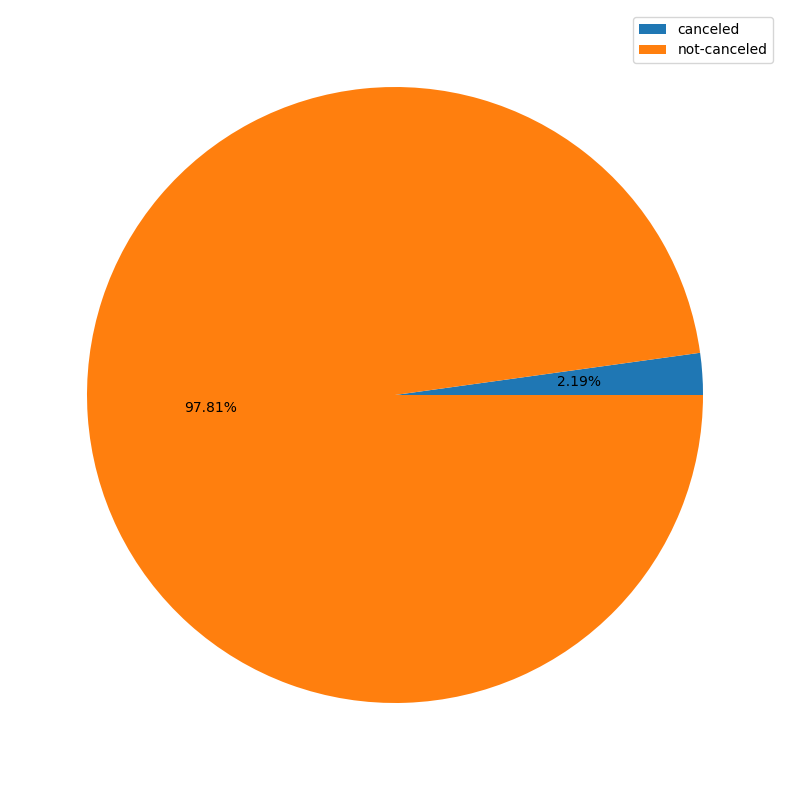

In [14]:
df_cancellations = pd.DataFrame({
    "type" : ["canceled","not-canceled"],
    "quantity": [len(df_cancel),len(df_no_cancel)]
})
df_cancellations

plt.figure(figsize = (10,10))
plt.pie(df_cancellations["quantity"], autopct="%1.2f%%")
plt.legend(df_cancellations["type"])
plt.show()

Quantity / Product description


In [15]:
df_description = df.groupby("stockcode")["description"].value_counts().sort_values(ascending=False).reset_index()
df_description


,stockcode,description,count
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2070
1,22423,REGENCY CAKESTAND 3 TIER,1905
2,85099B,JUMBO BAG RED RETROSPOT,1662
3,84879,ASSORTED COLOUR BIRD ORNAMENT,1418
4,47566,PARTY BUNTING,1416
...,...,...,...
3911,84839,SWEETHEART KEY CABINET,1
3912,90214T,"LETTER ""T"" BLING KEY RING",1
3913,90199B,5 STRAND GLASS NECKLACE AMETHYST,1
3914,90214O,"LETTER ""O"" BLING KEY RING",1


Total spend per country


In [16]:
df_no_cancel["total spend"] = df_no_cancel["quantity"] * df_no_cancel["unitprice"]
df_country = df_no_cancel.groupby("country")["total spend"].value_counts().reset_index()
df_country["total spend"] = df_country["total spend"] * df_country["count"]
df_country = df_country.groupby("country")["total spend"].sum().sort_values(ascending=False).reset_index()
df_country["porcentage"] = (df_country["total spend"] / df_country["total spend"].sum() * 100).round(2)
df_country


/tmp/ipython-input-503/3775950533.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_cancel["total spend"] = df_no_cancel["quantity"] * df_no_cancel["unitprice"]


,country,total spend,porcentage
0,United Kingdom,7308391.554,82.01
1,Netherlands,285446.340,3.20
2,EIRE,265545.900,2.98
3,Germany,228867.140,2.57
4,France,209024.050,2.35
5,Australia,138521.310,1.55
6,Spain,61577.110,0.69
7,Switzerland,56443.950,0.63
8,Belgium,41196.340,0.46
9,Sweden,38378.330,0.43


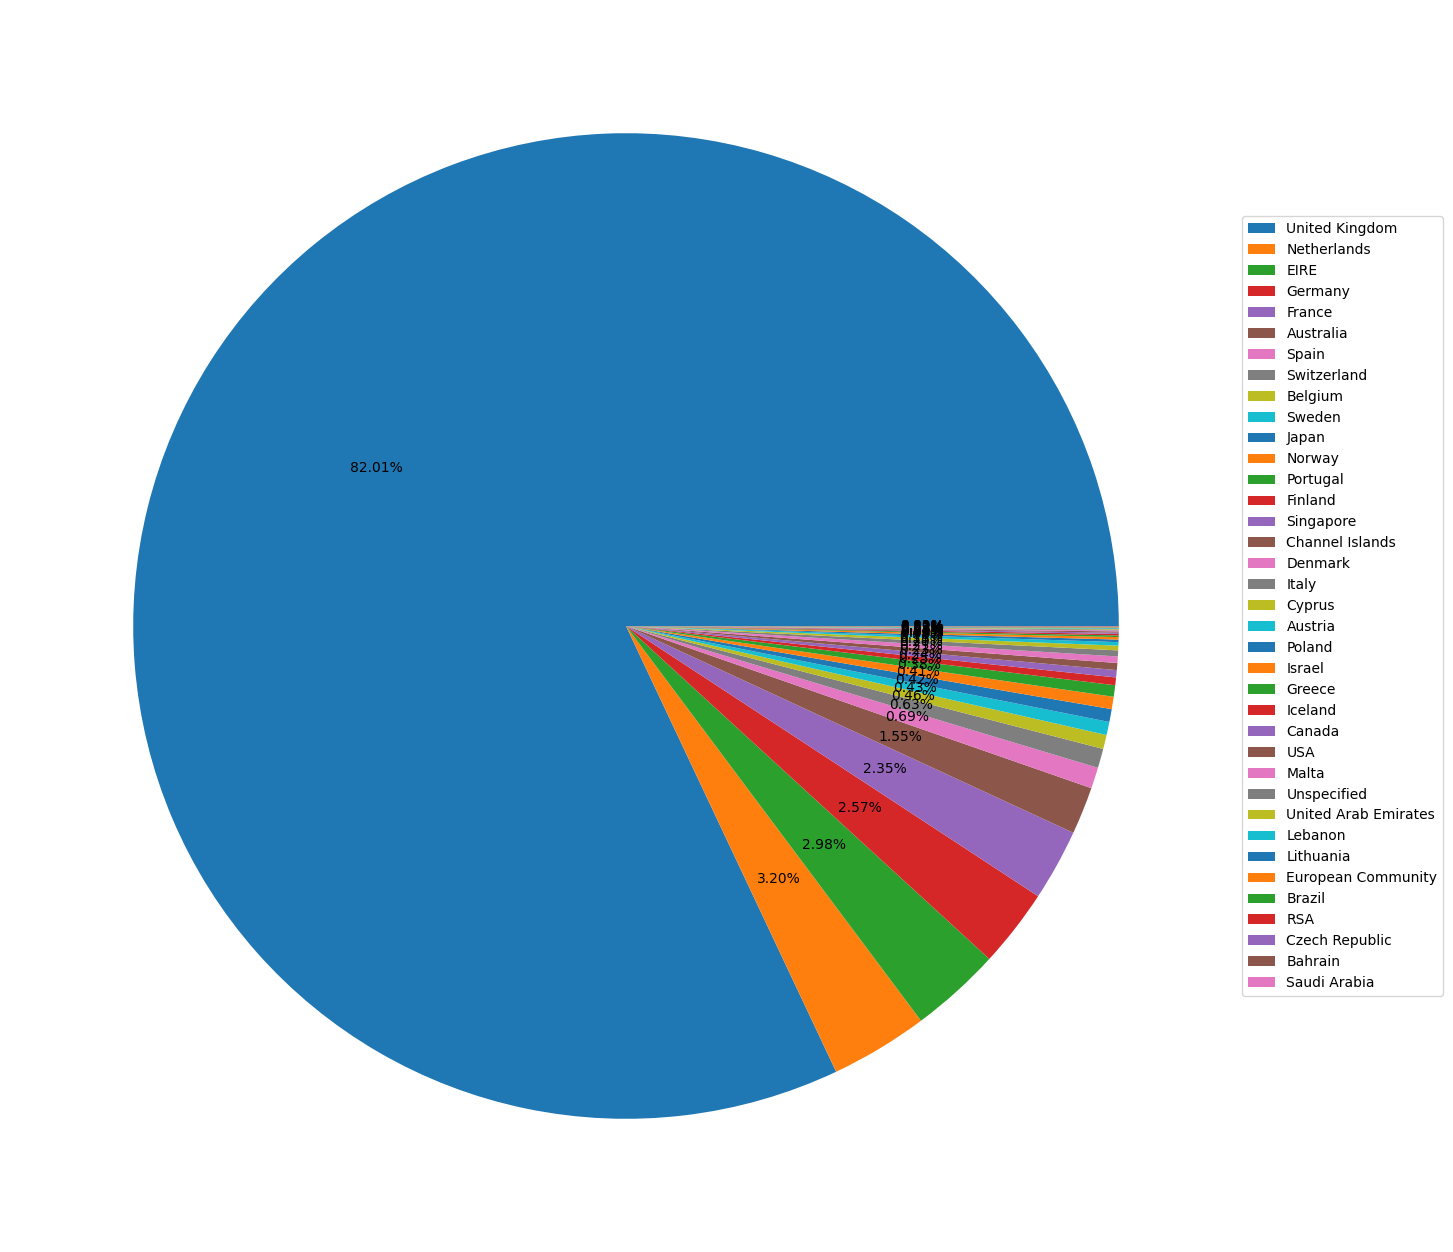

In [17]:

plt.figure(figsize = (16,16) )
plt.pie(df_country["total spend"], autopct="%1.2f%%")
plt.legend(df_country["country"],loc=(1,0.2))
plt.show()


From the non‑cancelled DataFrame, we display the total spend for each customer.

In [18]:
df_customer_id = df_no_cancel.groupby("customerid")["total spend"].value_counts().reset_index()
df_customer_id["total spend"] = df_customer_id["total spend"] * df_customer_id["count"]


df_customer_id = df_customer_id.groupby("customerid")["total spend"].sum().reset_index()
df_customer_id

,customerid,total spend
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4334,18280.0,180.60
4335,18281.0,80.82
4336,18282.0,178.05
4337,18283.0,2094.88


From the non‑cancelled DataFrame, we display how many days have passed since each customer’s last purchase.

In [19]:
date = df_no_cancel["invoicedate"].max()
df_recency = df_no_cancel.groupby("customerid")["invoicedate"].max().reset_index()
df_recency["days_since_last_purchase"] = (date - df_recency["invoicedate"]).dt.days
df_recency = df_recency.sort_values(by = "days_since_last_purchase", ascending=False,).reset_index()
df_recency

,index,customerid,invoicedate,days_since_last_purchase
0,4181,18074.0,2010-12-01 09:53:00,373
1,355,12791.0,2010-12-01 11:27:00,373
2,1750,14729.0,2010-12-01 12:43:00,373
3,3104,16583.0,2010-12-01 12:03:00,373
4,1038,13747.0,2010-12-01 10:37:00,373
...,...,...,...,...
4334,471,12955.0,2011-12-08 16:29:00,0
4335,71,12433.0,2011-12-09 10:02:00,0
4336,1695,14653.0,2011-12-08 13:45:00,0
4337,61,12423.0,2011-12-09 10:10:00,0


From the non‑cancelled DataFrame, we display each customer’s purchase frequency.

In [20]:
frecuency_df_customer_id = df_no_cancel.groupby("customerid")["invoiceno"].nunique().reset_index()
frecuency_df_customer_id




,customerid,invoiceno
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1
...,...,...
4334,18280.0,1
4335,18281.0,1
4336,18282.0,2
4337,18283.0,16


We merge Recency, Frequency, and Monetary into the same dataset.

In [21]:

rmf = df_recency.merge(frecuency_df_customer_id, on="customerid")
rmf = rmf.merge(df_customer_id, on="customerid")
rmf

,index,customerid,invoicedate,days_since_last_purchase,invoiceno,total spend
0,4181,18074.0,2010-12-01 09:53:00,373,1,489.60
1,355,12791.0,2010-12-01 11:27:00,373,1,192.60
2,1750,14729.0,2010-12-01 12:43:00,373,1,313.49
3,3104,16583.0,2010-12-01 12:03:00,373,1,233.45
4,1038,13747.0,2010-12-01 10:37:00,373,1,79.60
...,...,...,...,...,...,...
4334,471,12955.0,2011-12-08 16:29:00,0,11,4757.16
4335,71,12433.0,2011-12-09 10:02:00,0,7,13375.87
4336,1695,14653.0,2011-12-08 13:45:00,0,7,1947.55
4337,61,12423.0,2011-12-09 10:10:00,0,8,1859.31


We are applying a log transform to Frequency and Monetary.

In [22]:
import numpy as np

rmf["frecuency"] = np.log1p(rmf["invoiceno"])
rmf["monetary"] = np.log1p(rmf["total spend"])
rmf

,index,customerid,invoicedate,days_since_last_purchase,invoiceno,total spend,frecuency,monetary
0,4181,18074.0,2010-12-01 09:53:00,373,1,489.60,0.693147,6.195629
1,355,12791.0,2010-12-01 11:27:00,373,1,192.60,0.693147,5.265794
2,1750,14729.0,2010-12-01 12:43:00,373,1,313.49,0.693147,5.750952
3,3104,16583.0,2010-12-01 12:03:00,373,1,233.45,0.693147,5.457242
4,1038,13747.0,2010-12-01 10:37:00,373,1,79.60,0.693147,4.389499
...,...,...,...,...,...,...,...,...
4334,471,12955.0,2011-12-08 16:29:00,0,11,4757.16,2.484907,8.467616
4335,71,12433.0,2011-12-09 10:02:00,0,7,13375.87,2.079442,9.501282
4336,1695,14653.0,2011-12-08 13:45:00,0,7,1947.55,2.079442,7.574841
4337,61,12423.0,2011-12-09 10:10:00,0,8,1859.31,2.197225,7.528498


We have decided to choose K‑Means clustering as the algorithm, because we consider it will work better than others for this problem and can help us identify customer categories and whether a customer is active or inactive.

In [23]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score


scaler = RobustScaler()
data = ["days_since_last_purchase","frecuency","monetary"]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", scaler, data)
    ]
)

best_score = -1
best_k = None

X = rmf[data].copy()

for k in range(2, 9):
    pipeline = Pipeline(steps=[
        ("preprocessing", preprocessing),
        ("model", KMeans(n_clusters=k, random_state=42))
    ])

    X_transformed = pipeline.named_steps["preprocessing"].fit_transform(X)
    labels = pipeline.named_steps["model"].fit_predict(X_transformed)

    score = silhouette_score(X_transformed, labels)

    print(f"k={k} → silhouette={score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print("\nMejor número de clusters:", best_k)
print("Mejor silhouette score:", best_score)


k=2 → silhouette=0.3901
k=3 → silhouette=0.4216
k=4 → silhouette=0.3716
k=5 → silhouette=0.3396
k=6 → silhouette=0.3278
k=7 → silhouette=0.2926
k=8 → silhouette=0.2988

Mejor número de clusters: 3
Mejor silhouette score: 0.4216007588106187


In [24]:
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessing),
    ("model", KMeans(n_clusters=3, random_state=42))
])

pipeline.fit(X)

# Obtener clusters
rmf["cluster"] = pipeline.predict(X)

# Ver promedios reales (sin escala)
segment_summary = rmf.groupby("cluster")[data].mean()

print(segment_summary)

         days_since_last_purchase  frecuency  monetary
cluster                                               
0                       53.319095   1.050253  6.106739
1                       29.441176   2.140871  7.991381
2                      253.744186   0.845745  5.644556


In [25]:
rmf["segment"] = rmf["cluster"].map({
    0: "Regulares",
    1: "VIP",
    2: "Dormidos"
})


rmf["segment"].value_counts()


,count
segment,
Regulares,1990
VIP,1360
Dormidos,989


In [26]:
import plotly.express as px

# Creamos el gráfico 3D
fig = px.scatter_3d(
    rmf,
    x='days_since_last_purchase',
    y='frecuency',
    z='monetary',
    color='segment',  # VIP, Regulares, Dormidos
    size='monetary',  # opcional, para resaltar clientes de alto valor
    hover_data=['days_since_last_purchase', 'frecuency', 'monetary'],  # info al pasar el mouse
    color_discrete_map={'VIP':'gold','Regulares':'blue','Dormidos':'gray'},
    opacity=0.7
)

fig.update_layout(
    title='Segmentación RFM - Clusters Interactivos',
    scene=dict(
        xaxis_title='Recency (days)',
        yaxis_title='Frequency',
        zaxis_title='Monetary'
    ),
    legend_title='Segmentos'
)

fig.show()